# Load Neural Dynamics Data

This notebook loads and processes Atanas 2023 neural activity data from JSON files into numpy format for use in the main attention learning pipeline.


In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import os


In [2]:
# List all available JSON files
data_dir = Path('../data/dynamics/wormwideweb/json')
json_files = sorted(list(data_dir.glob('*.json')))
print(f"Found {len(json_files)} JSON files")
for f in json_files:
    print(f"  {f.name}")


Found 21 JSON files
  atanas_kim_2023-2022-06-14-01.json
  atanas_kim_2023-2022-06-14-07.json
  atanas_kim_2023-2022-06-14-13.json
  atanas_kim_2023-2022-06-28-01.json
  atanas_kim_2023-2022-06-28-07.json
  atanas_kim_2023-2022-07-15-06.json
  atanas_kim_2023-2022-07-15-12.json
  atanas_kim_2023-2022-07-20-01.json
  atanas_kim_2023-2022-07-26-01.json
  atanas_kim_2023-2022-08-02-01.json
  atanas_kim_2023-2023-01-09-28.json
  atanas_kim_2023-2023-01-17-01.json
  atanas_kim_2023-2023-01-19-01.json
  atanas_kim_2023-2023-01-19-08.json
  atanas_kim_2023-2023-01-19-15.json
  atanas_kim_2023-2023-01-19-22.json
  atanas_kim_2023-2023-01-23-01.json
  atanas_kim_2023-2023-01-23-08.json
  atanas_kim_2023-2023-01-23-15.json
  atanas_kim_2023-2023-01-23-21.json
  atanas_kim_2023-2023-03-07-01.json


In [3]:
# Load first JSON file (or specify by name)
json_file = json_files[0]
print(f"\nLoading: {json_file.name}")

with open(json_file, 'r') as f:
    data = json.load(f)

# Extract key information
print(f"Available keys: {data.keys()}")



Loading: atanas_kim_2023-2022-06-14-01.json
Available keys: dict_keys(['avg_timestep', 'rel_enc_str_θh', 'trace_original', 'dorsalness', 'head_curvature', 'angular_velocity', 'trace_array', 'rel_enc_str_P', 'reversal_events', 'encoding_changing_neurons', 'feedingness', 'uid', 'ranges', 'labeled', 'timestamp_confocal', 'velocity', 'body_curvature', 'forwardness', 'tau_vals', 'num_neurons', 'rel_enc_str_v', 'max_t', 'dataset_type', 'pumping', 'neuron_categorization'])


In [4]:
# Get neural activity data
trace_array = np.array(data['trace_array'])  # (N_neurons, time)
labeled = data['labeled']  # Dict with neuron information

print(f"\nData shapes:")
print(f"  trace_array: {trace_array.shape}")
print(f"  labeled: {len(labeled)} neurons")
print(f"  Time points: {trace_array.shape[1]}")



Data shapes:
  trace_array: (109, 1600)
  labeled: 79 neurons
  Time points: 1600


In [5]:
# Fix: Extract only labeled neurons and their information
print("Fixing data extraction...")

# Extract only the labeled neurons from trace_array
labeled_indices = [int(idx)-1 for idx in labeled.keys()] # change from 1-indexed to 0-indexed
labeled_trace_array = trace_array[labeled_indices, :]  # (N_labeled, time)

print(f"\nAfter filtering to labeled neurons:")
print(f"  labeled_trace_array: {labeled_trace_array.shape}")
print(f"  Number of labeled neurons: {len(labeled_indices)}")

# Extract neuron labels and classes
neuron_labels = [neuron_info['label'] for neuron_info in labeled.values()]
neuron_classes = [neuron_info['neuron_class'] for neuron_info in labeled.values()]

print(f"\nNeuron information:")
print(f"  Total labeled neurons: {len(neuron_labels)}")
print(f"  Unique neuron classes: {len(set(neuron_classes))}")
print(f"  Sample classes: {list(set(neuron_classes))[:10]}")

# Show sample neuron information
print(f"\nSample neuron details:")
for i, (idx, neuron_info) in enumerate(list(labeled.items())[:5]):
    print(f"  {i}: Index {idx} -> {neuron_info['label']} ({neuron_info['neuron_class']})")


Fixing data extraction...

After filtering to labeled neurons:
  labeled_trace_array: (79, 1600)
  Number of labeled neurons: 79

Neuron information:
  Total labeled neurons: 79
  Unique neuron classes: 41
  Sample classes: ['RME', 'M4', 'NSM', 'URA', 'OLQ', 'AVD', 'FLP', 'I1', 'AUA', 'SAA']

Sample neuron details:
  0: Index 32 -> CEPVR (CEP)
  1: Index 109 -> RMDR (RMD)
  2: Index 81 -> SAADR (SAA)
  3: Index 54 -> RMEL (RME)
  4: Index 78 -> AIBR (AIB)


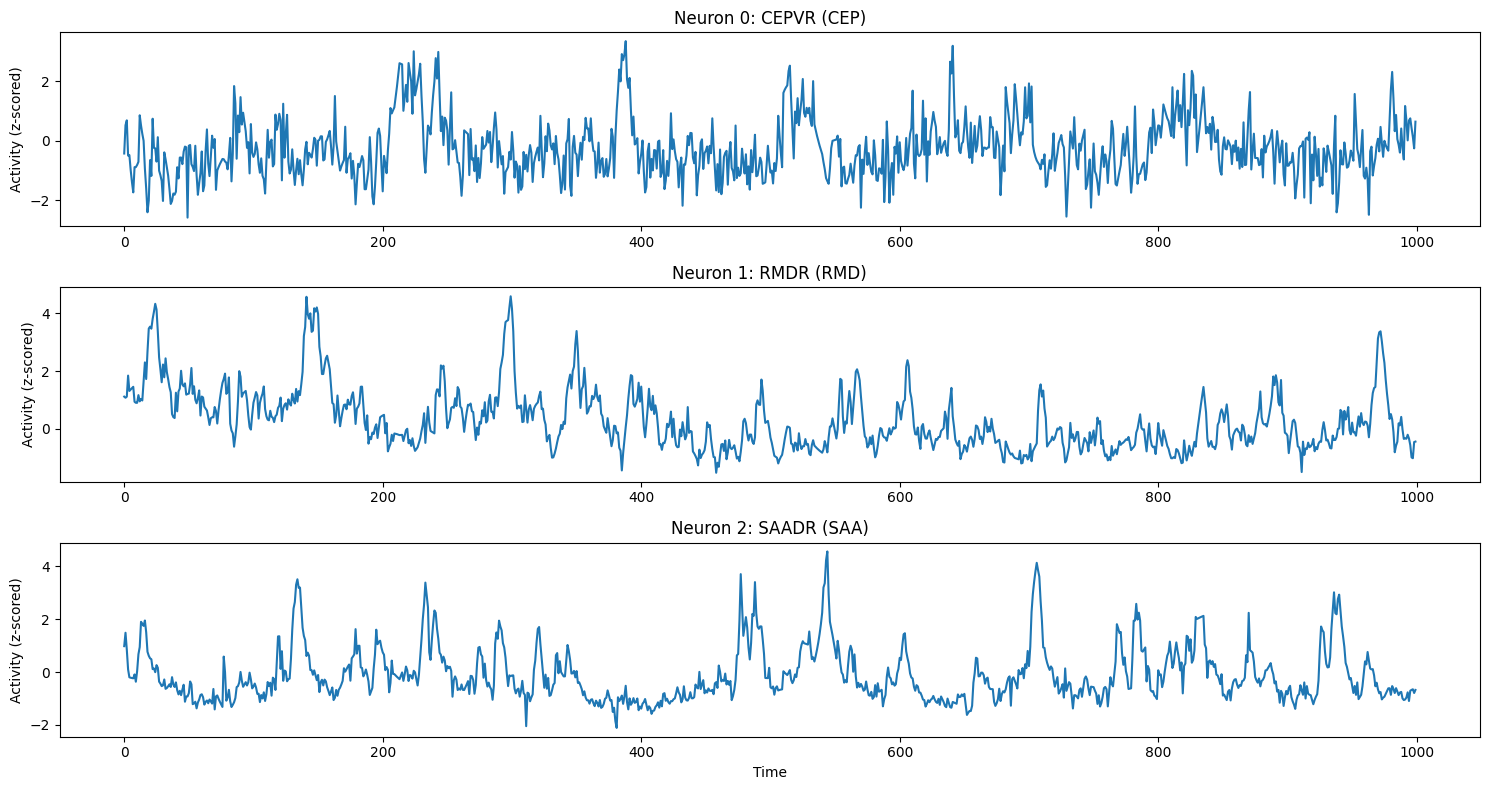

In [6]:
# Visualize sample traces (using filtered data)
fig, axes = plt.subplots(3, 1, figsize=(15, 8))
for i in range(min(3, len(neuron_labels))):
    axes[i].plot(labeled_trace_array[i, :1000])  # Plot first 1000 timepoints
    axes[i].set_title(f'Neuron {i}: {neuron_labels[i]} ({neuron_classes[i]})')
    axes[i].set_ylabel('Activity (z-scored)')
axes[-1].set_xlabel('Time')
plt.tight_layout()
plt.show()


In [8]:
# Save processed data (using filtered data)
output_dir = Path('../data/dynamics/wormwideweb/processed')
output_dir.mkdir(exist_ok=True)

output_file = output_dir / f"{json_file.stem}_processed.npz"
np.savez(output_file,
         trace_array=labeled_trace_array,  # Use filtered trace array
         neuron_labels=neuron_labels,      # List of neuron labels
         neuron_classes=neuron_classes,   # List of neuron classes
         labeled_indices=labeled_indices,  # Original indices in full array
         metadata={'source': json_file.name,
                   'n_neurons': labeled_trace_array.shape[0],
                   'n_timepoints': labeled_trace_array.shape[1],
                   'n_total_neurons': trace_array.shape[0]})

print(f"\nSaved processed data to: {output_file}")
print(f"  Filtered trace array: {labeled_trace_array.shape}")
print(f"  Neuron labels: {len(neuron_labels)}")
print(f"  Neuron classes: {len(neuron_classes)}")



Saved processed data to: ../data/dynamics/wormwideweb/processed/atanas_kim_2023-2022-06-14-01_processed.npz
  Filtered trace array: (79, 1600)
  Neuron labels: 79
  Neuron classes: 79
